## Stress tensor

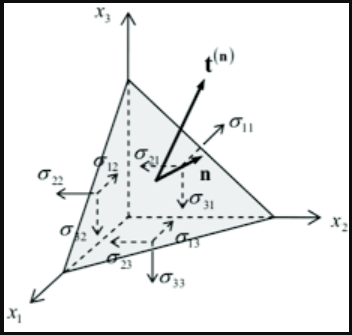

Consider any reference solid body. Assuming the hypothesis of a continuous body is valid, let us consider an arbitrary point in the body. At this point, we define an arbitrary system of Cartesian coordinates $Oxyz$, and an arbitrary orthonormal basis of vectors $\hat{a}, \hat{b}, \hat{c}$. We draw an infinitely small tetrahedron such that one of its vertices coincides with point $O$, and the orthogonal faces of the tetrahedron have outward normal vectors coinciding with $\hat{a}, \hat{b}, \hat{c}$. We will say that $\hat{n}$ is the outward normal of the oblique face of the tetrahedron.

We define the physical vector quantity stress $\vec{\Sigma} (\hat{n})$ as the force acting on a surface per unit area. Its dimensions are thus the same as those of pressure.

The stress tensor $\underline{\underline{\sigma}}$ at point $O$ is defined as:

\begin{equation*}
    \sigma _{ij} = a_j \, \Sigma_i \, (\hat{a}) + b_j \, \Sigma_i \, (\hat{b}) + c_j \, \Sigma_i \, (\hat{c})
\end{equation*}

And the i-th component of the stress exerted by the oblique wall outward, is given by:

\begin{equation*}
    \Sigma _i (\hat{n}) = \sigma _{ij} \, n_j \quad \text{sum over j}
\end{equation*}

And the i-th component of the unit vector $\hat{n}$ is related to the unit vectors $\hat{a}, \hat{b}, \hat{c}$ by:

\begin{equation*}
    n_ i = \frac{a_i + b_i + c_i}{\sqrt{(a_j + b_j + c_j) ^ 2}} \quad \text{sum over j}
\end{equation*}

It can be demonstrated that the stress tensor is symmetric by imposing the condition that the tetrahedron does not rotate around any Cartesian axis.

In [1]:
# Importing SymPy
import sympy as smp

In [2]:
# a, b, c are the unit vectors defining the orientation of the crystal
a_x, a_y, a_z = smp.symbols("a_x, a_y, a_z", real = True)
b_x, b_y, b_z = smp.symbols("b_x, b_y, b_z", real = True)
c_x, c_y, c_z = smp.symbols("c_x, c_y, c_z", real = True)

# Sa, Sb, Sc are the components of the stress vectors acting on the orthogonal faces of the crystal
S_xa, S_ya, S_za = smp.symbols(
    "\\Sigma_x(\\hat{a}), \\Sigma_y(\\hat{a}), \\Sigma_z(\\hat{a})", real = True)

S_xb, S_yb, S_zb = smp.symbols(
    "\\Sigma_x(\\hat{b}), \\Sigma_y(\\hat{b}), \\Sigma_z(\\hat{b})", real = True)

S_xc, S_yc, S_zc = smp.symbols(
    "\\Sigma_x(\\hat{c}), \\Sigma_y(\\hat{c}), \\Sigma_z(\\hat{c})", real = True)

In [3]:
# Defining the vectors
a = smp.Matrix([a_x,
                a_y,
                a_z])

b = smp.Matrix([b_x,
                b_y,
                b_z])

c = smp.Matrix([c_x,
                c_y,
                c_z])

S_X = smp.Matrix([S_xa,
                  S_xb,
                  S_xc])

S_Y = smp.Matrix([S_ya,
                  S_yb,
                  S_yc])

S_Z = smp.Matrix([S_za,
                  S_zb,
                  S_zc])

X = smp.Matrix([a_x,
                b_x,
                c_x])

Y = smp.Matrix([a_y,
                b_y,
                c_y])

Z = smp.Matrix([a_z,
                b_z,
                c_z])

In [4]:
# Defining the unit vector n
n = a + b + c
n = n / n.norm() # Normalizing
n

Matrix([
[(a_x + b_x + c_x)/sqrt((a_x + b_x + c_x)**2 + (a_y + b_y + c_y)**2 + (a_z + b_z + c_z)**2)],
[(a_y + b_y + c_y)/sqrt((a_x + b_x + c_x)**2 + (a_y + b_y + c_y)**2 + (a_z + b_z + c_z)**2)],
[(a_z + b_z + c_z)/sqrt((a_x + b_x + c_x)**2 + (a_y + b_y + c_y)**2 + (a_z + b_z + c_z)**2)]])

In [5]:
# Stress tensor
stress_tensor = smp.Matrix([[X.dot(S_X), Y.dot(S_X), Z.dot(S_X)],
                            [Y.dot(S_X), Y.dot(S_Y), Z.dot(S_Y)],
                            [Z.dot(S_X), Z.dot(S_Y), Z.dot(S_Z)]])
stress_tensor

Matrix([
[\Sigma_x(\hat{a})*a_x + \Sigma_x(\hat{b})*b_x + \Sigma_x(\hat{c})*c_x, \Sigma_x(\hat{a})*a_y + \Sigma_x(\hat{b})*b_y + \Sigma_x(\hat{c})*c_y, \Sigma_x(\hat{a})*a_z + \Sigma_x(\hat{b})*b_z + \Sigma_x(\hat{c})*c_z],
[\Sigma_x(\hat{a})*a_y + \Sigma_x(\hat{b})*b_y + \Sigma_x(\hat{c})*c_y, \Sigma_y(\hat{a})*a_y + \Sigma_y(\hat{b})*b_y + \Sigma_y(\hat{c})*c_y, \Sigma_y(\hat{a})*a_z + \Sigma_y(\hat{b})*b_z + \Sigma_y(\hat{c})*c_z],
[\Sigma_x(\hat{a})*a_z + \Sigma_x(\hat{b})*b_z + \Sigma_x(\hat{c})*c_z, \Sigma_y(\hat{a})*a_z + \Sigma_y(\hat{b})*b_z + \Sigma_y(\hat{c})*c_z, \Sigma_z(\hat{a})*a_z + \Sigma_z(\hat{b})*b_z + \Sigma_z(\hat{c})*c_z]])

In [6]:
# Stress on the n-face
stress_n = stress_tensor * n
stress_n

Matrix([
[(a_x + b_x + c_x)*(\Sigma_x(\hat{a})*a_x + \Sigma_x(\hat{b})*b_x + \Sigma_x(\hat{c})*c_x)/sqrt((a_x + b_x + c_x)**2 + (a_y + b_y + c_y)**2 + (a_z + b_z + c_z)**2) + (a_y + b_y + c_y)*(\Sigma_x(\hat{a})*a_y + \Sigma_x(\hat{b})*b_y + \Sigma_x(\hat{c})*c_y)/sqrt((a_x + b_x + c_x)**2 + (a_y + b_y + c_y)**2 + (a_z + b_z + c_z)**2) + (a_z + b_z + c_z)*(\Sigma_x(\hat{a})*a_z + \Sigma_x(\hat{b})*b_z + \Sigma_x(\hat{c})*c_z)/sqrt((a_x + b_x + c_x)**2 + (a_y + b_y + c_y)**2 + (a_z + b_z + c_z)**2)],
[(a_x + b_x + c_x)*(\Sigma_x(\hat{a})*a_y + \Sigma_x(\hat{b})*b_y + \Sigma_x(\hat{c})*c_y)/sqrt((a_x + b_x + c_x)**2 + (a_y + b_y + c_y)**2 + (a_z + b_z + c_z)**2) + (a_y + b_y + c_y)*(\Sigma_y(\hat{a})*a_y + \Sigma_y(\hat{b})*b_y + \Sigma_y(\hat{c})*c_y)/sqrt((a_x + b_x + c_x)**2 + (a_y + b_y + c_y)**2 + (a_z + b_z + c_z)**2) + (a_z + b_z + c_z)*(\Sigma_y(\hat{a})*a_z + \Sigma_y(\hat{b})*b_z + \Sigma_y(\hat{c})*c_z)/sqrt((a_x + b_x + c_x)**2 + (a_y + b_y + c_y)**2 + (a_z + b_z + c_z)**2)],

The geometric meaning of the stress tensor remains elusive if we focus solely on the general definition that was provided. Therefore, to simplify the expressions describing its coefficients, we choose to orient the tetrahedron such that the outward-pointing normal unit vectors of the orthogonal faces coincide with the unit vectors of the canonical basis we initially established. In this way, we have:

\begin{equation*}
    \sigma _{ij} = \Sigma_i \, (\hat{x_j})
\end{equation*}

Thus, it can be observed that the i-th j-th term of the stress tensor represents the i-th component of the stress acting on the j-th face

For example, the first term $\Sigma_x \, (\hat{x})$ represents the $x$-component of the stress acting on the $x$-face. The second term $\Sigma_x \, (\hat{y})$ is the $x$-component of the stress acting on the $y$-face, and so on

The chosen sign convention is as follows:
- If the coefficient is positive, the considered component points outward

- If the coefficient is negative, the considered component points inward

In [7]:
# Changing the vector basis Oabc -> Oxyz then a = x, b = y and c = z unit vectors
S_xx, S_xy, S_xz = smp.symbols(
    "\\Sigma_x_x, \\Sigma_x_y, \\Sigma_x_z", real = True)

S_yx, S_yy, S_yz = smp.symbols(
    "\\Sigma_x_y, \\Sigma_y_y, \\Sigma_y_z", real = True)

S_zx, S_zy, S_zz = smp.symbols(
    "\\Sigma_x_z, \\Sigma_y_z, \\Sigma_z_z", real = True)

Oxyz = {
    a_x: 1,
    a_y: 0,
    a_z: 0,
    b_x: 0,
    b_y: 1,
    b_z: 0,
    c_x: 0,
    c_y: 0,
    c_z: 1,
    S_xa: S_xx,
    S_ya: S_yx,
    S_za: S_zx,
    S_xb: S_xy,
    S_yb: S_yy,
    S_zb: S_zy,
    S_xc: S_xz,
    S_yc: S_yz,
    S_zc: S_zz
}

In [8]:
stress_tensor_Oxyz = stress_tensor.subs(Oxyz)
stress_tensor_Oxyz

Matrix([
[\Sigma_x_x, \Sigma_x_y, \Sigma_x_z],
[\Sigma_x_y, \Sigma_y_y, \Sigma_y_z],
[\Sigma_x_z, \Sigma_y_z, \Sigma_z_z]])

In [9]:
stress_n_Oxyz = stress_n.subs(Oxyz)
stress_n_Oxyz

Matrix([
[sqrt(3)*\Sigma_x_x/3 + sqrt(3)*\Sigma_x_y/3 + sqrt(3)*\Sigma_x_z/3],
[sqrt(3)*\Sigma_x_y/3 + sqrt(3)*\Sigma_y_y/3 + sqrt(3)*\Sigma_y_z/3],
[sqrt(3)*\Sigma_x_z/3 + sqrt(3)*\Sigma_y_z/3 + sqrt(3)*\Sigma_z_z/3]])

By the spectral theorem, one of the most important results in linear algebra, it follows that the stress tensor is diagonalizable, and this has significant consequences. One of these is that there exists a choice of spatial configuration that diagonalizes the tensor. The unit vectors of the diagonalizing basis define the so-called principal stress axes, where the stress is entirely normal and not tangential:

In [10]:
# Diagonalized Stress tensor
sigma_1, sigma_2, sigma_3 = smp.symbols("\\sigma_1, \\sigma_2, \\sigma_3", real = True)
smp.Matrix.diag([sigma_1, sigma_2, sigma_3])

Matrix([
[\sigma_1,        0,        0],
[       0, \sigma_2,        0],
[       0,        0, \sigma_3]])

Attention! The stress exerted by the oblique face outward (or more generally by the faces of the tetrahedron) is not necessarily parallel to the outward unit vector. In fact, it is not correct to speak of stress acting along a direction; it is more accurate to speak of stress acting on a face with a given outward normal. Let us calculate the cross product between the stress of a face and its normal:

\begin{equation*}
    \vec{\Sigma} (\hat{n}) \, \times \hat{n}
\end{equation*}

In [11]:
# Computing the cross product
cross = stress_n.cross(n).applyfunc(smp.simplify)
cross

Matrix([
[(-(a_y + b_y + c_y)*((a_x + b_x + c_x)*(\Sigma_x(\hat{a})*a_z + \Sigma_x(\hat{b})*b_z + \Sigma_x(\hat{c})*c_z) + (a_y + b_y + c_y)*(\Sigma_y(\hat{a})*a_z + \Sigma_y(\hat{b})*b_z + \Sigma_y(\hat{c})*c_z) + (a_z + b_z + c_z)*(\Sigma_z(\hat{a})*a_z + \Sigma_z(\hat{b})*b_z + \Sigma_z(\hat{c})*c_z)) + (a_z + b_z + c_z)*((a_x + b_x + c_x)*(\Sigma_x(\hat{a})*a_y + \Sigma_x(\hat{b})*b_y + \Sigma_x(\hat{c})*c_y) + (a_y + b_y + c_y)*(\Sigma_y(\hat{a})*a_y + \Sigma_y(\hat{b})*b_y + \Sigma_y(\hat{c})*c_y) + (a_z + b_z + c_z)*(\Sigma_y(\hat{a})*a_z + \Sigma_y(\hat{b})*b_z + \Sigma_y(\hat{c})*c_z)))/((a_x + b_x + c_x)**2 + (a_y + b_y + c_y)**2 + (a_z + b_z + c_z)**2)],
[ ((a_x + b_x + c_x)*((a_x + b_x + c_x)*(\Sigma_x(\hat{a})*a_z + \Sigma_x(\hat{b})*b_z + \Sigma_x(\hat{c})*c_z) + (a_y + b_y + c_y)*(\Sigma_y(\hat{a})*a_z + \Sigma_y(\hat{b})*b_z + \Sigma_y(\hat{c})*c_z) + (a_z + b_z + c_z)*(\Sigma_z(\hat{a})*a_z + \Sigma_z(\hat{b})*b_z + \Sigma_z(\hat{c})*c_z)) - (a_z + b_z + c_z)*((a_x + b

In [12]:
# Changing basis Oxyz -> Oabc
cross_Oxyz = cross.subs(Oxyz).applyfunc(smp.simplify)
cross_Oxyz

Matrix([
[ \Sigma_x_y/3 - \Sigma_x_z/3 + \Sigma_y_y/3 - \Sigma_z_z/3],
[-\Sigma_x_x/3 - \Sigma_x_y/3 + \Sigma_y_z/3 + \Sigma_z_z/3],
[ \Sigma_x_x/3 + \Sigma_x_z/3 - \Sigma_y_y/3 - \Sigma_y_z/3]])

As you can see, in general, this cross product is not zero. Therefore, it cannot be said that the stress is along the direction of n, because otherwise, we would have obtained zero for any choice of the coordinate system. Let's seek the solution to get the cross product zero:

In [13]:
eq1 = smp.Eq(cross_Oxyz[0], 0)
eq2 = smp.Eq(cross_Oxyz[1], 0)
eq3 = smp.Eq(cross_Oxyz[2], 0)

# S_xx, S_yy
sol = smp.solve([eq1, eq2, eq3], [S_xx, S_yy])
sol

{\Sigma_x_x: -\Sigma_x_y + \Sigma_y_z + \Sigma_z_z,
 \Sigma_y_y: -\Sigma_x_y + \Sigma_x_z + \Sigma_z_z}

In [14]:
# S_zz
(S_xx + S_yy + 2 * S_xy - S_xz - S_yz) / 2

\Sigma_x_x/2 + \Sigma_x_y - \Sigma_x_z/2 + \Sigma_y_y/2 - \Sigma_y_z/2

Given some initial configuration of the tetrahedron, let us assume that the unit vectors $\hat{a}, \hat{b}, \hat{c}$ undergo some infinitesimal variation in their coordinates (the tetrahedron changes configuration). We can then rewrite the tensor:

In [15]:
# Deviations
da_x, da_y, da_z = smp.symbols("da_x, da_y, da_z", real = True)
db_x, db_y, db_z = smp.symbols("db_x, db_y, db_z", real = True)
dc_x, dc_y, dc_z = smp.symbols("dc_x, dc_y, dc_z", real = True)

x, y, z = smp.symbols("x, y, z", real = True)

Let us substitute the new values for $\hat{a}, \hat{b}, \hat{c}$. Furthermore, let us expand the stresses to the first order in Taylor series as shown:

In [16]:
# Developing the stress tensor
subs_taylor = {
    a_x: a_x + da_x,
    a_y: a_y + da_y,
    a_z: a_z + da_z,
    b_x: b_x + db_x,
    b_y: b_y + db_y,
    b_z: b_z + db_z,
    c_x: c_x + dc_x,
    c_y: c_y + dc_y,
    c_z: c_z + dc_z,
    S_xa: S_xa + smp.Derivative(S_xa, x, 1) * da_x + smp.Derivative(S_xa, y, 1) * da_y + smp.Derivative(S_xa, z, 1) * da_z,
    S_ya: S_ya + smp.Derivative(S_ya, x, 1) * da_x + smp.Derivative(S_ya, y, 1) * da_y + smp.Derivative(S_ya, z, 1) * da_z,
    S_za: S_za + smp.Derivative(S_za, x, 1) * da_x + smp.Derivative(S_za, y, 1) * da_y + smp.Derivative(S_za, z, 1) * da_z,
    S_xb: S_xb + smp.Derivative(S_xb, x, 1) * db_x + smp.Derivative(S_xb, y, 1) * db_y + smp.Derivative(S_xb, z, 1) * db_z,
    S_yb: S_yb + smp.Derivative(S_yb, x, 1) * db_x + smp.Derivative(S_yb, y, 1) * db_y + smp.Derivative(S_yb, z, 1) * db_z,
    S_zb: S_zb + smp.Derivative(S_zb, x, 1) * db_x + smp.Derivative(S_zb, y, 1) * db_y + smp.Derivative(S_zb, z, 1) * db_z,
    S_xc: S_xc + smp.Derivative(S_xc, x, 1) * dc_x + smp.Derivative(S_xc, y, 1) * dc_y + smp.Derivative(S_xc, z, 1) * dc_z,
    S_yc: S_yc + smp.Derivative(S_yc, x, 1) * dc_x + smp.Derivative(S_yc, y, 1) * dc_y + smp.Derivative(S_yc, z, 1) * dc_z,
    S_zc: S_zc + smp.Derivative(S_zc, x, 1) * dc_x + smp.Derivative(S_zc, y, 1) * dc_y + smp.Derivative(S_zc, z, 1) * dc_z
}

In [17]:
stress_tensor_taylor = stress_tensor.subs(subs_taylor)
stress_tensor_taylor

Matrix([
[(a_x + da_x)*(\Sigma_x(\hat{a}) + da_x*Derivative(\Sigma_x(\hat{a}), x) + da_y*Derivative(\Sigma_x(\hat{a}), y) + da_z*Derivative(\Sigma_x(\hat{a}), z)) + (b_x + db_x)*(\Sigma_x(\hat{b}) + db_x*Derivative(\Sigma_x(\hat{b}), x) + db_y*Derivative(\Sigma_x(\hat{b}), y) + db_z*Derivative(\Sigma_x(\hat{b}), z)) + (c_x + dc_x)*(\Sigma_x(\hat{c}) + dc_x*Derivative(\Sigma_x(\hat{c}), x) + dc_y*Derivative(\Sigma_x(\hat{c}), y) + dc_z*Derivative(\Sigma_x(\hat{c}), z)), (a_y + da_y)*(\Sigma_x(\hat{a}) + da_x*Derivative(\Sigma_x(\hat{a}), x) + da_y*Derivative(\Sigma_x(\hat{a}), y) + da_z*Derivative(\Sigma_x(\hat{a}), z)) + (b_y + db_y)*(\Sigma_x(\hat{b}) + db_x*Derivative(\Sigma_x(\hat{b}), x) + db_y*Derivative(\Sigma_x(\hat{b}), y) + db_z*Derivative(\Sigma_x(\hat{b}), z)) + (c_y + dc_y)*(\Sigma_x(\hat{c}) + dc_x*Derivative(\Sigma_x(\hat{c}), x) + dc_y*Derivative(\Sigma_x(\hat{c}), y) + dc_z*Derivative(\Sigma_x(\hat{c}), z)), (a_z + da_z)*(\Sigma_x(\hat{a}) + da_x*Derivative(\Sigma_x(\ha

Now, let us calculate the difference between the final stress tensor and the initial one

In [18]:
diff = stress_tensor_taylor - stress_tensor
diff

Matrix([
[-\Sigma_x(\hat{a})*a_x - \Sigma_x(\hat{b})*b_x - \Sigma_x(\hat{c})*c_x + (a_x + da_x)*(\Sigma_x(\hat{a}) + da_x*Derivative(\Sigma_x(\hat{a}), x) + da_y*Derivative(\Sigma_x(\hat{a}), y) + da_z*Derivative(\Sigma_x(\hat{a}), z)) + (b_x + db_x)*(\Sigma_x(\hat{b}) + db_x*Derivative(\Sigma_x(\hat{b}), x) + db_y*Derivative(\Sigma_x(\hat{b}), y) + db_z*Derivative(\Sigma_x(\hat{b}), z)) + (c_x + dc_x)*(\Sigma_x(\hat{c}) + dc_x*Derivative(\Sigma_x(\hat{c}), x) + dc_y*Derivative(\Sigma_x(\hat{c}), y) + dc_z*Derivative(\Sigma_x(\hat{c}), z)), -\Sigma_x(\hat{a})*a_y - \Sigma_x(\hat{b})*b_y - \Sigma_x(\hat{c})*c_y + (a_y + da_y)*(\Sigma_x(\hat{a}) + da_x*Derivative(\Sigma_x(\hat{a}), x) + da_y*Derivative(\Sigma_x(\hat{a}), y) + da_z*Derivative(\Sigma_x(\hat{a}), z)) + (b_y + db_y)*(\Sigma_x(\hat{b}) + db_x*Derivative(\Sigma_x(\hat{b}), x) + db_y*Derivative(\Sigma_x(\hat{b}), y) + db_z*Derivative(\Sigma_x(\hat{b}), z)) + (c_y + dc_y)*(\Sigma_x(\hat{c}) + dc_x*Derivative(\Sigma_x(\hat{c}), x

In [19]:
# Function to eliminate all products (cross-terms and duplicates)
def eliminate_cross_terms(expr):
    symbols = [da_x, da_y, da_z, db_x, db_y, db_z, dc_x, dc_y, dc_z]
    for s1 in symbols:
        for s2 in symbols:
            expr = expr.expand().subs(s1 * s2, 0)
    return expr

In [20]:
# Final result (general formula)
diff = diff.applyfunc(lambda x: eliminate_cross_terms(expr = x))
diff

Matrix([
[\Sigma_x(\hat{a})*da_x + \Sigma_x(\hat{b})*db_x + \Sigma_x(\hat{c})*dc_x + a_x*da_x*Derivative(\Sigma_x(\hat{a}), x) + a_x*da_y*Derivative(\Sigma_x(\hat{a}), y) + a_x*da_z*Derivative(\Sigma_x(\hat{a}), z) + b_x*db_x*Derivative(\Sigma_x(\hat{b}), x) + b_x*db_y*Derivative(\Sigma_x(\hat{b}), y) + b_x*db_z*Derivative(\Sigma_x(\hat{b}), z) + c_x*dc_x*Derivative(\Sigma_x(\hat{c}), x) + c_x*dc_y*Derivative(\Sigma_x(\hat{c}), y) + c_x*dc_z*Derivative(\Sigma_x(\hat{c}), z), \Sigma_x(\hat{a})*da_y + \Sigma_x(\hat{b})*db_y + \Sigma_x(\hat{c})*dc_y + a_y*da_x*Derivative(\Sigma_x(\hat{a}), x) + a_y*da_y*Derivative(\Sigma_x(\hat{a}), y) + a_y*da_z*Derivative(\Sigma_x(\hat{a}), z) + b_y*db_x*Derivative(\Sigma_x(\hat{b}), x) + b_y*db_y*Derivative(\Sigma_x(\hat{b}), y) + b_y*db_z*Derivative(\Sigma_x(\hat{b}), z) + c_y*dc_x*Derivative(\Sigma_x(\hat{c}), x) + c_y*dc_y*Derivative(\Sigma_x(\hat{c}), y) + c_y*dc_z*Derivative(\Sigma_x(\hat{c}), z), \Sigma_x(\hat{a})*da_z + \Sigma_x(\hat{b})*db_z + 

Let us now try to study a notable case: suppose the tetrahedron has rotated around the unit vector $\hat{z}$ by an infinitesimal angle. Let us calculate the correction to the tensor:

In [21]:
# Defining a infinitesimal rotation around the z-axis
d_theta = smp.symbols("d\\theta", real = True)

R = smp.Matrix([[1, - d_theta, 0],
                [d_theta, 1, 0],
                [0, 0, 1]])

da = R * a - a
db = R * b - b
dc = R * c - c

subs_dd = {
    da_x: da[0],
    da_y: da[1],
    da_z: da[2],
    db_x: db[0],
    db_y: db[1],
    db_z: db[2],
    dc_x: dc[0],
    dc_y: dc[1],
    dc_z: dc[2]
}

In [22]:
# Correction to the tensor
rotated_diff = diff.subs(subs_dd).applyfunc(lambda x: smp.collect(x, d_theta))
rotated_diff

Matrix([
[d\theta*(-\Sigma_x(\hat{a})*a_y - \Sigma_x(\hat{b})*b_y - \Sigma_x(\hat{c})*c_y + a_x**2*Derivative(\Sigma_x(\hat{a}), y) - a_x*a_y*Derivative(\Sigma_x(\hat{a}), x) + b_x**2*Derivative(\Sigma_x(\hat{b}), y) - b_x*b_y*Derivative(\Sigma_x(\hat{b}), x) + c_x**2*Derivative(\Sigma_x(\hat{c}), y) - c_x*c_y*Derivative(\Sigma_x(\hat{c}), x)), d\theta*(\Sigma_x(\hat{a})*a_x + \Sigma_x(\hat{b})*b_x + \Sigma_x(\hat{c})*c_x + a_x*a_y*Derivative(\Sigma_x(\hat{a}), y) - a_y**2*Derivative(\Sigma_x(\hat{a}), x) + b_x*b_y*Derivative(\Sigma_x(\hat{b}), y) - b_y**2*Derivative(\Sigma_x(\hat{b}), x) + c_x*c_y*Derivative(\Sigma_x(\hat{c}), y) - c_y**2*Derivative(\Sigma_x(\hat{c}), x)), d\theta*(a_x*a_z*Derivative(\Sigma_x(\hat{a}), y) - a_y*a_z*Derivative(\Sigma_x(\hat{a}), x) + b_x*b_z*Derivative(\Sigma_x(\hat{b}), y) - b_y*b_z*Derivative(\Sigma_x(\hat{b}), x) + c_x*c_z*Derivative(\Sigma_x(\hat{c}), y) - c_y*c_z*Derivative(\Sigma_x(\hat{c}), x))],
[ d\theta*(\Sigma_x(\hat{a})*a_x + \Sigma_x(\hat{

We have correctly obtained a first-order correction in $d \theta$ and a symmetric tensor.

In [23]:
# Whem Oabc -> Oxyz
rotated_diff_Oxyz = rotated_diff.subs(Oxyz).applyfunc(lambda x: smp.collect(x, d_theta))
rotated_diff_Oxyz

Matrix([
[d\theta*(-\Sigma_x_y + Derivative(\Sigma_x_x, y)), d\theta*(\Sigma_x_x - Derivative(\Sigma_x_y, x)), 0],
[ d\theta*(\Sigma_x_x - Derivative(\Sigma_x_y, x)), d\theta*(\Sigma_x_y - Derivative(\Sigma_y_y, x)), 0],
[                                                0,                                                0, 0]])

Let us now consider a similar problem: calculating the stress tensor when following a transformation of the coordinate system $Oxyz$. We'll consider an infinitesimal rotation around a general unit vector $\hat{m}$.
To preserve its symmetry and all its intrinsic quantities, such as eigenvalues or eigenvectors, the tensor undergoes a similarity transformation following a change of basis:

\begin{equation*}
    \underline{\underline{\sigma}}' = M \, \underline{\underline{\sigma}} \, M^{- 1}
\end{equation*}

Where M is the matrix that describes the trasformation. In our case it's:

\begin{equation*}
    \mathbf{R} = \mathbf{I} + \sin\theta \, \mathbf{K} + (1 - \cos\theta) \, \mathbf{K}^2
\end{equation*}

where $\mathbf{I}$ is the identity matrix, and $\mathbf{K}$ is the skew-symmetric matrix of $\hat{m}$:

\begin{equation*}
\mathbf{K} = \begin{pmatrix}
0 & -m_z & m_y \\
m_z & 0 & -m_x \\
-m_y & m_x & 0
\end{pmatrix}
\end{equation*}

In [24]:
# Rodrigues formula
m_x, m_y, m_z = smp.symbols("m_x, m_y, m_z", real = True)
theta = smp.symbols("\\theta", real = True)

K = smp.Matrix([[0, - m_z, m_y],
                [m_z, 0, - m_x],
                [- m_y, m_x, 0]])

R = smp.eye(3) + (smp.sin(theta) * K) + ((1 - smp.cos(theta)) * (K * K))
R_inv = R.subs(theta, - theta)

R

Matrix([
[   (1 - cos(\theta))*(-m_y**2 - m_z**2) + 1, m_x*m_y*(1 - cos(\theta)) - m_z*sin(\theta),  m_x*m_z*(1 - cos(\theta)) + m_y*sin(\theta)],
[m_x*m_y*(1 - cos(\theta)) + m_z*sin(\theta),    (1 - cos(\theta))*(-m_x**2 - m_z**2) + 1, -m_x*sin(\theta) + m_y*m_z*(1 - cos(\theta))],
[m_x*m_z*(1 - cos(\theta)) - m_y*sin(\theta), m_x*sin(\theta) + m_y*m_z*(1 - cos(\theta)),     (1 - cos(\theta))*(-m_x**2 - m_y**2) + 1]])

In [25]:
# Transforming the stress tensor
rotated_stress_tensor_theta_m = R * stress_tensor * R_inv
rotated_stress_tensor_theta_m

Matrix([
[   ((1 - cos(\theta))*(-m_y**2 - m_z**2) + 1)*(((1 - cos(\theta))*(-m_y**2 - m_z**2) + 1)*(\Sigma_x(\hat{a})*a_x + \Sigma_x(\hat{b})*b_x + \Sigma_x(\hat{c})*c_x) + (m_x*m_y*(1 - cos(\theta)) - m_z*sin(\theta))*(\Sigma_x(\hat{a})*a_y + \Sigma_x(\hat{b})*b_y + \Sigma_x(\hat{c})*c_y) + (m_x*m_z*(1 - cos(\theta)) + m_y*sin(\theta))*(\Sigma_x(\hat{a})*a_z + \Sigma_x(\hat{b})*b_z + \Sigma_x(\hat{c})*c_z)) + (m_x*m_y*(1 - cos(\theta)) - m_z*sin(\theta))*(((1 - cos(\theta))*(-m_y**2 - m_z**2) + 1)*(\Sigma_x(\hat{a})*a_y + \Sigma_x(\hat{b})*b_y + \Sigma_x(\hat{c})*c_y) + (m_x*m_y*(1 - cos(\theta)) - m_z*sin(\theta))*(\Sigma_y(\hat{a})*a_y + \Sigma_y(\hat{b})*b_y + \Sigma_y(\hat{c})*c_y) + (m_x*m_z*(1 - cos(\theta)) + m_y*sin(\theta))*(\Sigma_y(\hat{a})*a_z + \Sigma_y(\hat{b})*b_z + \Sigma_y(\hat{c})*c_z)) + (m_x*m_z*(1 - cos(\theta)) + m_y*sin(\theta))*(((1 - cos(\theta))*(-m_y**2 - m_z**2) + 1)*(\Sigma_x(\hat{a})*a_z + \Sigma_x(\hat{b})*b_z + \Sigma_x(\hat{c})*c_z) + (m_x*m_y*(1 - co

In [26]:
# For a infinitesimal rotation around the x, y, z-axis and even n
rotated_stress_tensor_d_theta_x = rotated_stress_tensor_theta_m.subs([(m_x, 1),
                                                                      (m_y, 0),
                                                                      (m_z, 0)]).subs([(smp.sin(theta), d_theta),
                                                                                       (smp.cos(theta), 1)])

rotated_stress_tensor_d_theta_y = rotated_stress_tensor_theta_m.subs([(m_x, 0),
                                                                      (m_y, 1),
                                                                      (m_z, 0)]).subs([(smp.sin(theta), d_theta),
                                                                                       (smp.cos(theta), 1)])

rotated_stress_tensor_d_theta_z = rotated_stress_tensor_theta_m.subs([(m_x, 0),
                                                                      (m_y, 0),
                                                                      (m_z, 1)]).subs([(smp.sin(theta), d_theta),
                                                                                       (smp.cos(theta), 1)])

rotated_stress_tensor_d_theta_n = rotated_stress_tensor_theta_m.subs([(m_x, n[0]),
                                                                      (m_y, n[1]),
                                                                      (m_z, n[2])]).subs([(smp.sin(theta), d_theta),
                                                                                          (smp.cos(theta), 1)])

# Correction tensors
diff_rotated_stress_tensor_d_theta_x = (rotated_stress_tensor_d_theta_x - stress_tensor).applyfunc(smp.expand).subs(d_theta ** 2, 0).applyfunc(lambda x: smp.collect(x, d_theta))
diff_rotated_stress_tensor_d_theta_y = (rotated_stress_tensor_d_theta_y - stress_tensor).applyfunc(smp.expand).subs(d_theta ** 2, 0).applyfunc(lambda x: smp.collect(x, d_theta))
diff_rotated_stress_tensor_d_theta_z = (rotated_stress_tensor_d_theta_z - stress_tensor).applyfunc(smp.expand).subs(d_theta ** 2, 0).applyfunc(lambda x: smp.collect(x, d_theta))
diff_rotated_stress_tensor_d_theta_n = (rotated_stress_tensor_d_theta_n - stress_tensor).applyfunc(smp.expand).subs(d_theta ** 2, 0).applyfunc(lambda x: smp.collect(x, d_theta))


In [27]:
diff_rotated_stress_tensor_d_theta_x

Matrix([
[                                                                               0,                                                                        d\theta*(-\Sigma_x(\hat{a})*a_z - \Sigma_x(\hat{b})*b_z - \Sigma_x(\hat{c})*c_z),                                                                         d\theta*(\Sigma_x(\hat{a})*a_y + \Sigma_x(\hat{b})*b_y + \Sigma_x(\hat{c})*c_y)],
[d\theta*(-\Sigma_x(\hat{a})*a_z - \Sigma_x(\hat{b})*b_z - \Sigma_x(\hat{c})*c_z),                                                                  d\theta*(-2*\Sigma_y(\hat{a})*a_z - 2*\Sigma_y(\hat{b})*b_z - 2*\Sigma_y(\hat{c})*c_z), d\theta*(\Sigma_y(\hat{a})*a_y + \Sigma_y(\hat{b})*b_y + \Sigma_y(\hat{c})*c_y - \Sigma_z(\hat{a})*a_z - \Sigma_z(\hat{b})*b_z - \Sigma_z(\hat{c})*c_z)],
[ d\theta*(\Sigma_x(\hat{a})*a_y + \Sigma_x(\hat{b})*b_y + \Sigma_x(\hat{c})*c_y), d\theta*(\Sigma_y(\hat{a})*a_y + \Sigma_y(\hat{b})*b_y + \Sigma_y(\hat{c})*c_y - \Sigma_z(\hat{a})*a_z - \Sigma_z(\hat{b})*b_z -

In [28]:
diff_rotated_stress_tensor_d_theta_y

Matrix([
[                                                                   d\theta*(2*\Sigma_x(\hat{a})*a_z + 2*\Sigma_x(\hat{b})*b_z + 2*\Sigma_x(\hat{c})*c_z),  d\theta*(\Sigma_y(\hat{a})*a_z + \Sigma_y(\hat{b})*b_z + \Sigma_y(\hat{c})*c_z), d\theta*(-\Sigma_x(\hat{a})*a_x - \Sigma_x(\hat{b})*b_x - \Sigma_x(\hat{c})*c_x + \Sigma_z(\hat{a})*a_z + \Sigma_z(\hat{b})*b_z + \Sigma_z(\hat{c})*c_z)],
[                                                                         d\theta*(\Sigma_y(\hat{a})*a_z + \Sigma_y(\hat{b})*b_z + \Sigma_y(\hat{c})*c_z),                                                                                0,                                                                         d\theta*(-\Sigma_x(\hat{a})*a_y - \Sigma_x(\hat{b})*b_y - \Sigma_x(\hat{c})*c_y)],
[d\theta*(-\Sigma_x(\hat{a})*a_x - \Sigma_x(\hat{b})*b_x - \Sigma_x(\hat{c})*c_x + \Sigma_z(\hat{a})*a_z + \Sigma_z(\hat{b})*b_z + \Sigma_z(\hat{c})*c_z), d\theta*(-\Sigma_x(\hat{a})*a_y - \Sigma_x(\hat{b})*

In [29]:
diff_rotated_stress_tensor_d_theta_z

Matrix([
[                                                                 d\theta*(-2*\Sigma_x(\hat{a})*a_y - 2*\Sigma_x(\hat{b})*b_y - 2*\Sigma_x(\hat{c})*c_y), d\theta*(\Sigma_x(\hat{a})*a_x + \Sigma_x(\hat{b})*b_x + \Sigma_x(\hat{c})*c_x - \Sigma_y(\hat{a})*a_y - \Sigma_y(\hat{b})*b_y - \Sigma_y(\hat{c})*c_y), d\theta*(-\Sigma_y(\hat{a})*a_z - \Sigma_y(\hat{b})*b_z - \Sigma_y(\hat{c})*c_z)],
[d\theta*(\Sigma_x(\hat{a})*a_x + \Sigma_x(\hat{b})*b_x + \Sigma_x(\hat{c})*c_x - \Sigma_y(\hat{a})*a_y - \Sigma_y(\hat{b})*b_y - \Sigma_y(\hat{c})*c_y),                                                                   d\theta*(2*\Sigma_x(\hat{a})*a_y + 2*\Sigma_x(\hat{b})*b_y + 2*\Sigma_x(\hat{c})*c_y),  d\theta*(\Sigma_x(\hat{a})*a_z + \Sigma_x(\hat{b})*b_z + \Sigma_x(\hat{c})*c_z)],
[                                                                       d\theta*(-\Sigma_y(\hat{a})*a_z - \Sigma_y(\hat{b})*b_z - \Sigma_y(\hat{c})*c_z),                                                          

In [30]:
# Changing the tetrahedon basis Oabc -> Oxyz
diff_rotated_stress_tensor_d_theta_x_Oxyz = diff_rotated_stress_tensor_d_theta_x.subs(Oxyz)
diff_rotated_stress_tensor_d_theta_y_Oxyz = diff_rotated_stress_tensor_d_theta_y.subs(Oxyz)
diff_rotated_stress_tensor_d_theta_z_Oxyz = diff_rotated_stress_tensor_d_theta_z.subs(Oxyz)
diff_rotated_stress_tensor_d_theta_n_Oxyz = diff_rotated_stress_tensor_d_theta_n.subs(Oxyz)

In [31]:
diff_rotated_stress_tensor_d_theta_x_Oxyz

Matrix([
[                  0,               -\Sigma_x_z*d\theta,                \Sigma_x_y*d\theta],
[-\Sigma_x_z*d\theta,             -2*\Sigma_y_z*d\theta, d\theta*(\Sigma_y_y - \Sigma_z_z)],
[ \Sigma_x_y*d\theta, d\theta*(\Sigma_y_y - \Sigma_z_z),              2*\Sigma_y_z*d\theta]])

In [32]:
diff_rotated_stress_tensor_d_theta_y_Oxyz

Matrix([
[              2*\Sigma_x_z*d\theta,  \Sigma_y_z*d\theta, d\theta*(-\Sigma_x_x + \Sigma_z_z)],
[                \Sigma_y_z*d\theta,                   0,                -\Sigma_x_y*d\theta],
[d\theta*(-\Sigma_x_x + \Sigma_z_z), -\Sigma_x_y*d\theta,              -2*\Sigma_x_z*d\theta]])

In [33]:
diff_rotated_stress_tensor_d_theta_z_Oxyz

Matrix([
[            -2*\Sigma_x_y*d\theta, d\theta*(\Sigma_x_x - \Sigma_y_y), -\Sigma_y_z*d\theta],
[d\theta*(\Sigma_x_x - \Sigma_y_y),              2*\Sigma_x_y*d\theta,  \Sigma_x_z*d\theta],
[              -\Sigma_y_z*d\theta,                \Sigma_x_z*d\theta,                   0]])

In [34]:
diff_rotated_stress_tensor_d_theta_n_Oxyz.applyfunc(smp.simplify)

Matrix([
[                        2*sqrt(3)*d\theta*(-\Sigma_x_y + \Sigma_x_z)/3,  sqrt(3)*d\theta*(\Sigma_x_x - \Sigma_x_z - \Sigma_y_y + \Sigma_y_z)/3, sqrt(3)*d\theta*(-\Sigma_x_x + \Sigma_x_y - \Sigma_y_z + \Sigma_z_z)/3],
[ sqrt(3)*d\theta*(\Sigma_x_x - \Sigma_x_z - \Sigma_y_y + \Sigma_y_z)/3,                          2*sqrt(3)*d\theta*(\Sigma_x_y - \Sigma_y_z)/3, sqrt(3)*d\theta*(-\Sigma_x_y + \Sigma_x_z + \Sigma_y_y - \Sigma_z_z)/3],
[sqrt(3)*d\theta*(-\Sigma_x_x + \Sigma_x_y - \Sigma_y_z + \Sigma_z_z)/3, sqrt(3)*d\theta*(-\Sigma_x_y + \Sigma_x_z + \Sigma_y_y - \Sigma_z_z)/3,                         2*sqrt(3)*d\theta*(-\Sigma_x_z + \Sigma_y_z)/3]])

Given a stress acting on a face with normal $\hat{n}$, we want to calculate the components parallel and orthogonal to the face

In [35]:
# Parallel component
parallel_n = stress_n.dot(n)
parallel_n

(a_x + b_x + c_x)*((a_x + b_x + c_x)*(\Sigma_x(\hat{a})*a_x + \Sigma_x(\hat{b})*b_x + \Sigma_x(\hat{c})*c_x)/sqrt((a_x + b_x + c_x)**2 + (a_y + b_y + c_y)**2 + (a_z + b_z + c_z)**2) + (a_y + b_y + c_y)*(\Sigma_x(\hat{a})*a_y + \Sigma_x(\hat{b})*b_y + \Sigma_x(\hat{c})*c_y)/sqrt((a_x + b_x + c_x)**2 + (a_y + b_y + c_y)**2 + (a_z + b_z + c_z)**2) + (a_z + b_z + c_z)*(\Sigma_x(\hat{a})*a_z + \Sigma_x(\hat{b})*b_z + \Sigma_x(\hat{c})*c_z)/sqrt((a_x + b_x + c_x)**2 + (a_y + b_y + c_y)**2 + (a_z + b_z + c_z)**2))/sqrt((a_x + b_x + c_x)**2 + (a_y + b_y + c_y)**2 + (a_z + b_z + c_z)**2) + (a_y + b_y + c_y)*((a_x + b_x + c_x)*(\Sigma_x(\hat{a})*a_y + \Sigma_x(\hat{b})*b_y + \Sigma_x(\hat{c})*c_y)/sqrt((a_x + b_x + c_x)**2 + (a_y + b_y + c_y)**2 + (a_z + b_z + c_z)**2) + (a_y + b_y + c_y)*(\Sigma_y(\hat{a})*a_y + \Sigma_y(\hat{b})*b_y + \Sigma_y(\hat{c})*c_y)/sqrt((a_x + b_x + c_x)**2 + (a_y + b_y + c_y)**2 + (a_z + b_z + c_z)**2) + (a_z + b_z + c_z)*(\Sigma_y(\hat{a})*a_z + \Sigma_y(\hat{b})*b_

In [36]:
# Swtiching to the Oabc system
parallel_n_Oxyz = parallel_n.subs(Oxyz).simplify()
parallel_n_Oxyz

\Sigma_x_x/3 + 2*\Sigma_x_y/3 + 2*\Sigma_x_z/3 + \Sigma_y_y/3 + 2*\Sigma_y_z/3 + \Sigma_z_z/3

In [37]:
# Orthogonal component
orthogonal_n = smp.sqrt(stress_n.dot(stress_n) - parallel_n ** 2)
orthogonal_n

sqrt(((a_x + b_x + c_x)*(\Sigma_x(\hat{a})*a_x + \Sigma_x(\hat{b})*b_x + \Sigma_x(\hat{c})*c_x)/sqrt((a_x + b_x + c_x)**2 + (a_y + b_y + c_y)**2 + (a_z + b_z + c_z)**2) + (a_y + b_y + c_y)*(\Sigma_x(\hat{a})*a_y + \Sigma_x(\hat{b})*b_y + \Sigma_x(\hat{c})*c_y)/sqrt((a_x + b_x + c_x)**2 + (a_y + b_y + c_y)**2 + (a_z + b_z + c_z)**2) + (a_z + b_z + c_z)*(\Sigma_x(\hat{a})*a_z + \Sigma_x(\hat{b})*b_z + \Sigma_x(\hat{c})*c_z)/sqrt((a_x + b_x + c_x)**2 + (a_y + b_y + c_y)**2 + (a_z + b_z + c_z)**2))**2 + ((a_x + b_x + c_x)*(\Sigma_x(\hat{a})*a_y + \Sigma_x(\hat{b})*b_y + \Sigma_x(\hat{c})*c_y)/sqrt((a_x + b_x + c_x)**2 + (a_y + b_y + c_y)**2 + (a_z + b_z + c_z)**2) + (a_y + b_y + c_y)*(\Sigma_y(\hat{a})*a_y + \Sigma_y(\hat{b})*b_y + \Sigma_y(\hat{c})*c_y)/sqrt((a_x + b_x + c_x)**2 + (a_y + b_y + c_y)**2 + (a_z + b_z + c_z)**2) + (a_z + b_z + c_z)*(\Sigma_y(\hat{a})*a_z + \Sigma_y(\hat{b})*b_z + \Sigma_y(\hat{c})*c_z)/sqrt((a_x + b_x + c_x)**2 + (a_y + b_y + c_y)**2 + (a_z + b_z + c_z)**2))*

In [38]:
# Switching to the Oabc system
orthogonal_n_Oxyz = orthogonal_n.subs(Oxyz).simplify()
orthogonal_n_Oxyz

sqrt(3*(\Sigma_x_x + \Sigma_x_y + \Sigma_x_z)**2 + 3*(\Sigma_x_y + \Sigma_y_y + \Sigma_y_z)**2 + 3*(\Sigma_x_z + \Sigma_y_z + \Sigma_z_z)**2 - (\Sigma_x_x + 2*\Sigma_x_y + 2*\Sigma_x_z + \Sigma_y_y + 2*\Sigma_y_z + \Sigma_z_z)**2)/3